# Experiment paraphrasing: Chunks

The goal of this experiment is to find out whether paraphrasing paragraphs or chunks (because the layout information used to identify paragraphs was stripped from the arrow datasets) is more effective paraphrasing whole texts in terms of state-of-the-art paraphrasing metrics.
We will paraphrase chunks and compute scores on chunk-paragraph level.
The scores will be averaged to get a score for the whole text, which will be compared to the score of the whole text paraphrased.

In [ ]:
from pathlib import Path
import os
import textwrap
import sys
import re
import nltk
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("punkt")
from nltk.tokenize import sent_tokenize, word_tokenize

# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from genai_detection.config import CONFIG
from genai_detection.paraphrasing.paraphraser import (
    T5ChatGPTParaphraser,
    T5GooglePAWSParaphraser,
    BlabladorParaphraser,
    BulletPointParaphraser,
    OllamaParaphraser,
    TaskParaphraser,
    TopicParaphraser,
    TitleParaphraser,
    TranslationParaphraser,
)
from genai_detection.paraphrasing.paraphraser_evaluation import ParaphrasingEvaluator

In [ ]:
path2results = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "paraphrasing"
    / "experiments"
)
category2directory = {  # value: directory name and one file name in the datasets folder
    "News": [
        "custom_texts",
        "cnn_040725",
    ],  # Dalai Lama; "cnn_230625"    # USA attacks Iran
    "Blog": ["blog_corpus", 27],
    "Gutenberg": ["gutenberg", "Othello_the_Moor_of_Venice_William_Shakespeare"],
    "Student Essay": [
        "student_essays/Intro2006",
        "Ass1/2006_AB4847",
    ],  # stream of consciousness essay: 18 years old girl who writes about her bipolar ex-boyfriend of 8 months and her new boyfriend who loves music like her but is not catholic; she wants to live in the present
}

# This is used for plot titles in the notebook
# data_category = "Blog" # done on 24.07.2025
data_category = "News"  # done on 23.07.2025
# data_category = "Gutenberg"
# data_category = "Student Essay"
path2datasets = (
    Path(os.getcwd()).resolve().parent
    / "data"
    / "datasets"
    / category2directory[data_category][0]
)

assert path2datasets.exists(), f"Path to datasets {path2datasets} does not exist."
assert path2results.exists(), f"Path to results {path2results} does not exist."

file_name = category2directory[data_category][1]
original_text = (
    open(path2datasets / f"{file_name}.txt").read()
    if data_category != "Blog"
    else pd.read_csv(path2datasets / f"blogtext.csv").loc[file_name, "text"]
)

print(textwrap.fill(original_text, width=80))

             This may be a long blog...got a lot of thoughts going through my
head this last couple of days, not least because of my reading  urlLink A
Mathematician Plays the Stock Market --a very cool book and one that I wish I
read before embarking on the  urlLink CFA  designation exams (wrote 2 of the 3
required exams already).  Anyhoo, went out for some drinks last night (yes,
Thursday night, a school night, but I really wanted to break this jetlag and I
find that going out is one of the most effective, and most fun, ways to do so)
at a little place called Han's Sausages near Hong-Ik University (usually
referred to as HongDae).  So upon ordering the bratwurst and beer I noticed
something interesting, the beer came in a special pitcher that has dry ice in a
compartment in the bottom of it and passages that allow the vapor to flow to the
top and escape.  Pretty cool idea, and I had seen it before in another bar in
Sinchon (another teen/bar district near HongDae).  While out on the t

In [ ]:
# path2datasets = (
#     Path(os.getcwd()).resolve().parent / "data" / "datasets" / "custom_texts"
# )
# data_category = "News"  # This is used for plot titles in the notebook
# path2results = (
#     Path(os.getcwd()).resolve().parent
#     / CONFIG.SAVE_PATH
#     / "paraphrasing"
#     / "experiments"
# )
# path2results.mkdir(parents=True, exist_ok=True)
# assert path2datasets.exists(), f"Path to datasets {path2datasets} does not exist."
# # file_name = "cnn_230625"    # USA attacks Iran
# file_name = "cnn_040725"  # Dalai Lama
# original_text = open(path2datasets / f"{file_name}.txt").read()

# print(textwrap.fill(original_text, width=80))

In [ ]:
n_responses = 1  # number of paraphrases to generate
max_length = 512  # Maximum length of the generated paraphrase
temperature = 0.7  # Controls the randomness of the output. Lower values make the output more deterministic.

prompts = [
    "Paraphrase the following text and output only the paraphrased version:",
    "First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):",
    "Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.",
    "Paraphrase the sentence using the same tone as the original with approximately the same number of words:",
    "Paraphrase this sentence. Do not change the meaning, but use different words and structure. Output only the paraphrased sentence:",
]

In [ ]:
ollama_model_id = {"name": "zephyr:7b", "model": "zephyr:7b"}
# {
#     "name": "mistral",
#     "model": "mistral:7b",
# }
# {"name":"Ollama-latest", "model":"default:latest"}
paraphrasers = {
    "T5_ChatGPT": T5ChatGPTParaphraser(),
    "T5_Google_PAWS": T5GooglePAWSParaphraser(),
    # "Blablador": BlabladorParaphraser(
    #     model_id="1 - Llama3 405 the best general model and big context size"
    # ),
    "Ollama": OllamaParaphraser(model_id=ollama_model_id["model"]),
}
if "Blablador" in paraphrasers.keys():
    print(
        "Available Blablador models:\n",
        paraphrasers["Blablador"]._get_available_models(verbose=False),
    )

models = {
    "text_extractor": {
        "name": ollama_model_id["name"],
        "model": OllamaParaphraser(model_id=ollama_model_id["model"]),
    },
    "text_generator": {
        "name": ollama_model_id["name"],
        "model": OllamaParaphraser(model_id=ollama_model_id["model"]),
    },
}
#'text_generator': {'name':'Blablador-Ministral8b', 'model':BlabladorParaphraser(model_id="1 - Ministral 8b - the fast model")}}
bullet_point_paraphraser = BulletPointParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)
task_paraphraser = TaskParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)
topic_paraphraser = TopicParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)
title_paraphraser = TitleParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)
translation_paraphraser = TranslationParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)
paraphrasers.update(
    {
        "BulletPoint": bullet_point_paraphraser,
        "Task": task_paraphraser,
        "Topic": topic_paraphraser,
        "Title": title_paraphraser,
        "Translation": translation_paraphraser,
    }
)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [ ]:
paraphrase_evaluator = ParaphrasingEvaluator(
    paraphrasers=paraphrasers,
    prompts=prompts,
    original_text=original_text,
    n_responses=n_responses,
    max_length=max_length,
    temperature=temperature,
)
one_paragr_df, _ = paraphrase_evaluator.evaluate(
    save_extremest_paraphr_per_score=True, save_to_disk=True
)
one_paragr_df

[DEBUG] Total configurations to evaluate: 40, [(('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the following text and output only the paraphrased version:', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the sentence using the same tone as t

Evaluating Paraphrasers: 100%|██████████| 40/40 [25:33<00:00, 38.33s/it] 


Results saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_results_comparison_temp0.7_maxLength512.csv


,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta
0,T5_ChatGPT,Paraphrase the following text and output only ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,"last night, i went out for drinks in a small b...",1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,distilbert-base-uncased_L5_no-idf_version=0.3....,0.591901,0.029510,0.562391
1,T5_ChatGPT,"First, extract bullet points capturing the mai...","{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,"last night, i went out for drinks in a small b...",1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,distilbert-base-uncased_L5_no-idf_version=0.3....,0.591901,0.029510,0.562391
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,"last night, i went out for drinks in a small b...",1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,distilbert-base-uncased_L5_no-idf_version=0.3....,0.591901,0.029510,0.562391
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,"last night, i went out for drinks in a small b...",1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,distilbert-base-uncased_L5_no-idf_version=0.3....,0.591901,0.029510,0.562391
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,"last night, i went out for drinks in a small b...",1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,distilbert-base-uncased_L5_no-idf_version=0.3....,0.591901,0.029510,0.562391
5,T5_Google_PAWS,Paraphrase the following text and output only ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,it's one reason why koreans often study themse...,2.210062e-07,0.032761,0.112403,0.060194,0.060078,0.060078,0.800964,0.721566,0.759195,0.111608,0.669568,distilbert-base-uncased_L5_no-idf_version=0.3....,0.612580,0.057494,0.555087
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...","{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,i actually saw a few people i knew from the un...,4.164115e-07,0.032445,0.108317,0.031008,0.063830,0.063830,0.804809,0.715302,0.757421,0.137570,0.659984,distilbert-base-uncased_L5_no-idf_version=0.3....,0.615017,0.057382,0.557635
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,how does this help us to understand korean cul...,2.051554e-46,0.005705,0.012295,0.004107,0.010246,0.010246,0.737015,0.583764,0.651498,0.054546,0.570108,distilbert-base-uncased_L5_no-idf_version=0.3....,0.519386,0.007514,0.511873
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,how do they tell a relationship if they are 'k...,7.965885e-07,0.034713,0.109932,0.050242,0.059788,0.059788,0.827216,0.715890,0.767537,0.119834,0.631044,distilbert-base-uncased_L5_no-idf_version=0.3....,0.612304,0.056574,0.555731
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...",this may be a long blog...got a lot of thought...,when i met a 

In [ ]:
def split_text_into_chunks(text, n):
    """
    Splits the input text into approximately n chunks, ensuring that each chunk has a similar number
    of words. The function first tokenizes the text into sentences, then groups these sentences into
    chunks such that the total word count in each chunk is roughly even across n parts.
    :param text: The input text to be split into chunks.
    :param n: The number of chunks to split the text into. If n is greater than the number of sentences, the function will return fewer chunks.
    :return: A list of text chunks, each containing approximately the same number of words.
    """
    # Step 1: Tokenize into sentences
    sentences = sent_tokenize(text)

    # Step 2: Group sentences until total word count is ~ even across n parts
    total_words = sum(len(word_tokenize(sent)) for sent in sentences)
    target_words_per_chunk = total_words / n

    chunks = []
    current_chunk = []
    current_word_count = 0

    for sent in sentences:
        sent_words = word_tokenize(sent)
        current_chunk.append(sent)
        current_word_count += len(sent_words)

        if current_word_count >= target_words_per_chunk and len(chunks) < n - 1:
            chunks.append(" ".join(current_chunk))
            current_chunk = []
            current_word_count = 0

    # Append remaining sentences to the last chunk
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    # In case we got fewer than n chunks (e.g., short text), pad empty
    # while len(chunks) < n:
    #     chunks.append("")

    return chunks

In [ ]:
for n_chunks in range(1, 6):
    print(f"\nParaphrasing with {n_chunks} chunks:")
    chunks = split_text_into_chunks(original_text, n_chunks)
    print(f"Number of chunks: {len(chunks)}")
    print(f"Chunks: {chunks}")
    for i, chunk in enumerate(chunks):
        print(f"Chunk {i}: {chunk[:50]}...")


Paraphrasing with 1 chunks:
Number of chunks: 1
Chunks: ["             This may be a long blog...got a lot of thoughts going through my head this last couple of days, not least because of my reading  urlLink A Mathematician Plays the Stock Market --a very cool book and one that I wish I read before embarking on the  urlLink CFA  designation exams (wrote 2 of the 3 required exams already). Anyhoo, went out for some drinks last night (yes, Thursday night, a school night, but I really wanted to break this jetlag and I find that going out is one of the most effective, and most fun, ways to do so) at a little place called Han's Sausages near Hong-Ik University (usually referred to as HongDae). So upon ordering the bratwurst and beer I noticed something interesting, the beer came in a special pitcher that has dry ice in a compartment in the bottom of it and passages that allow the vapor to flow to the top and escape. Pretty cool idea, and I had seen it before in another bar in Sinchon (anot

In [ ]:
one_paragr_df["n_chunks"] = 1  # Add a column to indicate the number of chunks
n_paragraphs_df = [one_paragr_df]
for num_chunks in tqdm(range(2, 6), desc="Evaluating with different chunk sizes"):
    chunks = split_text_into_chunks(original_text, n=num_chunks)
    print(f"Number of chunks: {num_chunks}")

    res_for_chunks = []
    for i, chunk in enumerate(chunks):
        paraphrase_evaluator = ParaphrasingEvaluator(
            paraphrasers=paraphrasers,
            prompts=prompts,
            original_text=chunk,
            n_responses=n_responses,
            max_length=max_length,
            temperature=temperature,
        )
        df, _ = paraphrase_evaluator.evaluate(
            save_extremest_paraphr_per_score=False, save_to_disk=False
        )
        df["n_chunks"] = num_chunks
        res_for_chunks.append(df)

    # Combine all dataframes
    df_concat = pd.concat(res_for_chunks)

    # Separate numeric and non-numeric columns
    numeric_df = df_concat.select_dtypes(include="number")
    non_numeric_df = df_concat.select_dtypes(exclude="number")

    # Take only the first non-numeric row per group to merge back later
    non_numeric_first = non_numeric_df.groupby(level=0).first()

    # Compute mean of numeric data
    numeric_mean = numeric_df.groupby(level=0).mean()

    # Combine them back together
    averaged_df = pd.concat([non_numeric_first, numeric_mean], axis=1)

    # Add to results list
    n_paragraphs_df.append(averaged_df)
print(f"Number of chunks tested: {len(n_paragraphs_df)}")

Evaluating with different chunk sizes:   0%|          | 0/4 [00:00<?, ?it/s]

Number of chunks: 2
[DEBUG] Total configurations to evaluate: 40, [(('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the following text and output only the paraphrased version:', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the sentence usin

Evaluating Paraphrasers: 100%|██████████| 40/40 [27:30<00:00, 41.27s/it]


[DEBUG] Total configurations to evaluate: 40, [(('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the following text and output only the paraphrased version:', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the sentence using the same tone as t

Again


...

[DEBUG] Total configurations to evaluate: 40, [(('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the following text and output only the paraphrased version:', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x394282490>), 'Paraphrase the sentence using the same tone as t

Again


Again


Evaluating with different chunk sizes: 100%|██████████| 4/4 [3:31:42<00:00, 3175.58s/it]

Number of chunks tested: 5


In [ ]:
def save_modelwise_chunk_scores(n_paragraphs_df, output_dir, data_category="News"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    full_df = pd.concat(n_paragraphs_df)
    for model_name, model_df in full_df.groupby("model"):
        # Group by prompt, sort by n_chunks
        model_df_sorted = model_df.sort_values(by=["prompt", "n_chunks"])

        # Save to CSV
        file_name = f"{model_name}_chunk_scores_category_{data_category}.csv"
        model_df_sorted.to_csv(output_dir / file_name, index=False)


save_modelwise_chunk_scores(
    n_paragraphs_df, output_dir=path2results, data_category=data_category
)

In [ ]:
slim_n_paragraphs_dfs = []
for i in range(len(n_paragraphs_df)):
    # each row is average score over scores of all chunks
    print(f"Chunk size: {i + 1}, number of score entries: {len(n_paragraphs_df[i])}")

    slim_n_paragraphs_df = n_paragraphs_df[i].drop(
        columns=[
            # "prompt",
            "original_text",
            "parameters",
            "paraphrased_text",
            "bertscore_hash",
        ]
    )
    # slim_n_paragraphs_df["n_chunks"] = i + 1  # index + 1 = number of chunks
    slim_n_paragraphs_dfs.append(slim_n_paragraphs_df)
    display(slim_n_paragraphs_df)

Chunk size: 1, number of score entries: 40


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,0.591901,0.029510,0.562391,1
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,0.591901,0.029510,0.562391,1
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,0.591901,0.029510,0.562391,1
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,0.591901,0.029510,0.562391,1
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,1.335501e-17,0.012467,0.048290,0.018145,0.040241,0.040241,0.834657,0.645087,0.727729,0.111680,0.640352,0.591901,0.029510,0.562391,1
5,T5_Google_PAWS,Paraphrase the following text and output only ...,2.210062e-07,0.032761,0.112403,0.060194,0.060078,0.060078,0.800964,0.721566,0.759195,0.111608,0.669568,0.612580,0.057494,0.555087,1
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",4.164115e-07,0.032445,0.108317,0.031008,0.063830,0.063830,0.804809,0.715302,0.757421,0.137570,0.659984,0.615017,0.057382,0.557635,1
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,2.051554e-46,0.005705,0.012295,0.004107,0.010246,0.010246,0.737015,0.583764,0.651498,0.054546,0.570108,0.519386,0.007514,0.511873,1
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,7.965885e-07,0.034713,0.109932,0.050242,0.059788,0.059788,0.827216,0.715890,0.767537,0.119834,0.631044,0.612304,0.056574,0.555731,1
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,1.031177e-06,0.040561,0.112294,0.062076,0.054211,0.054211,0.793397,0.717037,0.753286,0.114643,0.566720,0.589017,0.055502,0.533514,1


Chunk size: 2, number of score entries: 40


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,2.051819e-09,0.022960,0.078052,0.017532,0.062515,0.062515,0.808945,0.648370,0.719569,0.091294,0.731869,0.600009,0.046856,0.553154,2.0
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",2.051819e-09,0.022960,0.078052,0.017532,0.062515,0.062515,0.808945,0.648370,0.719569,0.091294,0.731869,0.600009,0.046856,0.553154,2.0
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,2.051819e-09,0.022960,0.078052,0.017532,0.062515,0.062515,0.808945,0.648370,0.719569,0.091294,0.731869,0.600009,0.046856,0.553154,2.0
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,2.051819e-09,0.022960,0.078052,0.017532,0.062515,0.062515,0.808945,0.648370,0.719569,0.091294,0.731869,0.600009,0.046856,0.553154,2.0
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,2.051819e-09,0.022960,0.078052,0.017532,0.062515,0.062515,0.808945,0.648370,0.719569,0.091294,0.731869,0.600009,0.046856,0.553154,2.0
5,T5_Google_PAWS,Paraphrase the following text and output only ...,5.784288e-04,0.079851,0.203135,0.122577,0.138931,0.138931,0.873154,0.734959,0.798101,0.159349,0.780647,0.669242,0.114215,0.555027,2.0
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",5.252168e-04,0.085255,0.209971,0.117647,0.142539,0.142539,0.844126,0.725835,0.780520,0.168346,0.697601,0.643286,0.117678,0.525607,2.0
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,3.798130e-03,0.097928,0.241357,0.183598,0.184839,0.184839,0.887621,0.735378,0.804223,0.185795,0.812819,0.685167,0.143331,0.541836,2.0
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,3.114119e-03,0.129395,0.256620,0.159104,0.190911,0.190911,0.819488,0.721986,0.767583,0.179839,0.761216,0.650022,0.150215,0.499807,2.0
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,3.036915e-03,0.119922,0.254926,0.195169,0.215846,0.215846,0.861224,0.743034,0.797775,0.195224,0.722563,0.663964,0.157937,0.506028,2.0


Chunk size: 3, number of score entries: 40


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,4.777538e-07,0.030725,0.082330,0.015609,0.051679,0.051679,0.781168,0.658129,0.714333,0.085939,0.746611,0.597236,0.044670,0.552566,3.0
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",1.788048e-05,0.034649,0.106443,0.025993,0.079468,0.079468,0.810765,0.662318,0.728751,0.074683,0.724350,0.600173,0.061976,0.538197,3.0
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,4.099138e-08,0.027767,0.076645,0.019715,0.048877,0.048877,0.789446,0.638579,0.705899,0.065177,0.674685,0.574757,0.041841,0.532917,3.0
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,6.784377e-07,0.031492,0.087785,0.013065,0.055470,0.055470,0.803112,0.668803,0.729800,0.078735,0.719720,0.600034,0.047752,0.552282,3.0
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,8.398833e-06,0.048048,0.112384,0.032364,0.079458,0.079458,0.810323,0.665422,0.730755,0.103802,0.713501,0.604760,0.063950,0.540810,3.0
5,T5_Google_PAWS,Paraphrase the following text and output only ...,1.518652e-02,0.159384,0.323025,0.257133,0.278021,0.278021,0.919112,0.751576,0.826906,0.168866,0.756464,0.684585,0.205411,0.479174,3.0
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",1.600722e-02,0.174640,0.322835,0.242663,0.286814,0.286814,0.913078,0.755825,0.827021,0.167395,0.753055,0.683275,0.208552,0.474723,3.0
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,2.299160e-02,0.174666,0.334549,0.260286,0.271043,0.271043,0.912667,0.761394,0.830194,0.192531,0.824963,0.704350,0.209528,0.494822,3.0
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,2.105848e-02,0.181941,0.338633,0.285850,0.307186,0.307186,0.927997,0.762381,0.837043,0.196662,0.768484,0.698513,0.222292,0.476221,3.0
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,1.983657e-02,0.182399,0.347934,0.282602,0.277996,0.277996,0.916204,0.770023,0.836764,0.190392,0.788672,0.700411,0.215255,0.485156,3.0


Chunk size: 4, number of score entries: 40


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,0.000028,0.037568,0.116380,0.021664,0.072799,0.072799,0.813841,0.673935,0.737280,0.090780,0.777969,0.618761,0.063069,0.555692,4.0
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",0.000060,0.054024,0.136631,0.045060,0.097065,0.097065,0.811649,0.673993,0.736439,0.091979,0.808562,0.624524,0.077919,0.546606,4.0
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,0.000020,0.038941,0.110257,0.011627,0.065559,0.065559,0.774818,0.664005,0.715055,0.087017,0.708828,0.589945,0.058612,0.531333,4.0
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,0.000507,0.063513,0.169793,0.048541,0.099717,0.099717,0.828357,0.692607,0.754073,0.108313,0.781222,0.632914,0.090006,0.542909,4.0
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,0.000037,0.041864,0.120442,0.037131,0.087089,0.087089,0.828299,0.655753,0.731716,0.090962,0.782489,0.617844,0.069189,0.548655,4.0
5,T5_Google_PAWS,Paraphrase the following text and output only ...,0.068903,0.252911,0.432541,0.367725,0.363856,0.363856,0.927678,0.794116,0.855676,0.227165,0.841526,0.729232,0.288433,0.440799,4.0
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",0.040833,0.189056,0.401667,0.309614,0.345451,0.345451,0.914007,0.787104,0.845777,0.215191,0.835912,0.719598,0.262650,0.456948,4.0
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,0.051214,0.227476,0.411000,0.324184,0.333688,0.333688,0.926433,0.787208,0.851135,0.202763,0.814446,0.716397,0.265301,0.451096,4.0
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,0.061577,0.235213,0.423836,0.337213,0.376403,0.376403,0.922567,0.786783,0.849255,0.231865,0.883788,0.734852,0.287272,0.447580,4.0
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,0.057247,0.218709,0.413997,0.336668,0.372055,0.372055,0.932091,0.788010,0.853933,0.223215,0.852111,0.729872,0.281100,0.448772,4.0


Chunk size: 5, number of score entries: 40


,model,prompt,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,sem_sim_avg,syn_sim_avg,gohsen_delta,n_chunks
0,T5_ChatGPT,Paraphrase the following text and output only ...,0.000295,0.062460,0.164415,0.039105,0.099209,0.099209,0.822223,0.691981,0.751189,0.091004,0.785888,0.628457,0.087973,0.540484,5.0
1,T5_ChatGPT,"First, extract bullet points capturing the mai...",0.000567,0.065842,0.156557,0.040550,0.100884,0.100884,0.828310,0.694721,0.755579,0.102476,0.757833,0.627784,0.086003,0.541781,5.0
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,0.000443,0.049223,0.122018,0.022309,0.086382,0.086382,0.774117,0.668833,0.717437,0.083229,0.682242,0.585171,0.069614,0.515557,5.0
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,0.001037,0.065370,0.166000,0.042506,0.094497,0.094497,0.811668,0.687898,0.744189,0.092504,0.784032,0.624058,0.087178,0.536880,5.0
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,0.000369,0.065684,0.163479,0.038854,0.099957,0.099957,0.824057,0.684044,0.747306,0.095588,0.765894,0.623378,0.087935,0.535443,5.0
5,T5_Google_PAWS,Paraphrase the following text and output only ...,0.159728,0.342590,0.524424,0.452131,0.461671,0.461671,0.939105,0.819295,0.875012,0.249049,0.833979,0.743288,0.381941,0.361347,5.0
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...",0.106124,0.279569,0.473398,0.359532,0.397812,0.397812,0.921647,0.804759,0.859015,0.205630,0.834592,0.725129,0.325778,0.399350,5.0
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,0.092907,0.268574,0.451125,0.351505,0.375647,0.375647,0.925721,0.795414,0.855450,0.204889,0.855253,0.727345,0.306560,0.420786,5.0
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,0.142029,0.325452,0.528349,0.436939,0.478611,0.478611,0.939483,0.815858,0.873196,0.238208,0.829534,0.739256,0.382997,0.356259,5.0
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,0.094748,0.266653,0.468066,0.379409,0.410306,0.410306,0.931852,0.796063,0.858245,0.219005,0.871073,0.735248,0.324374,0.410874,5.0


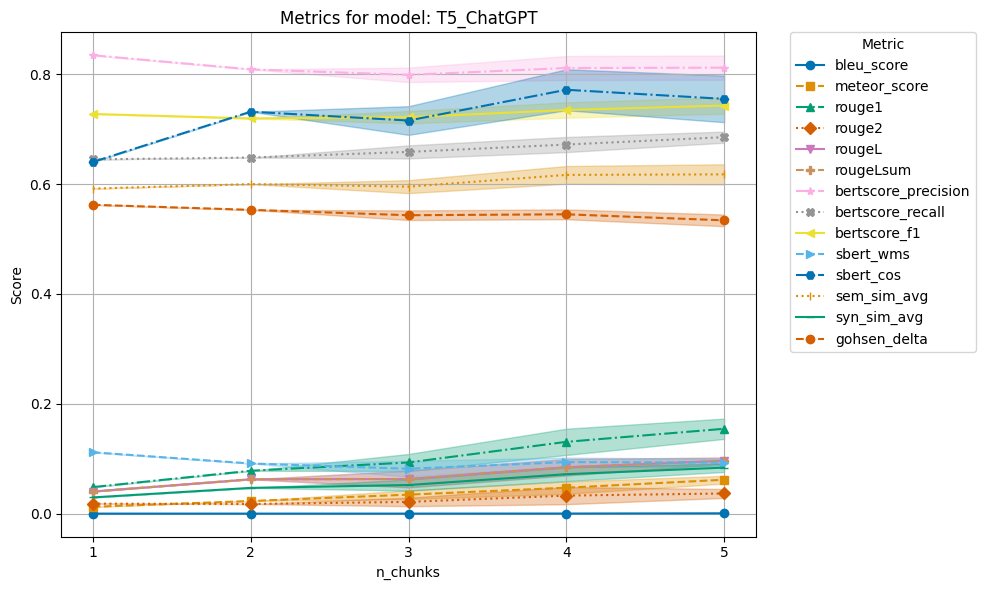

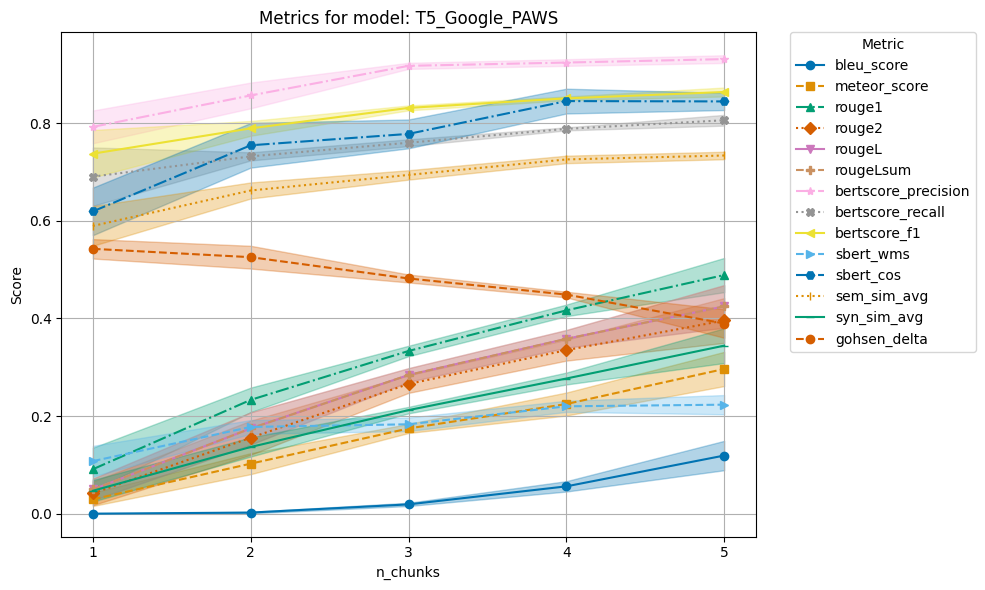

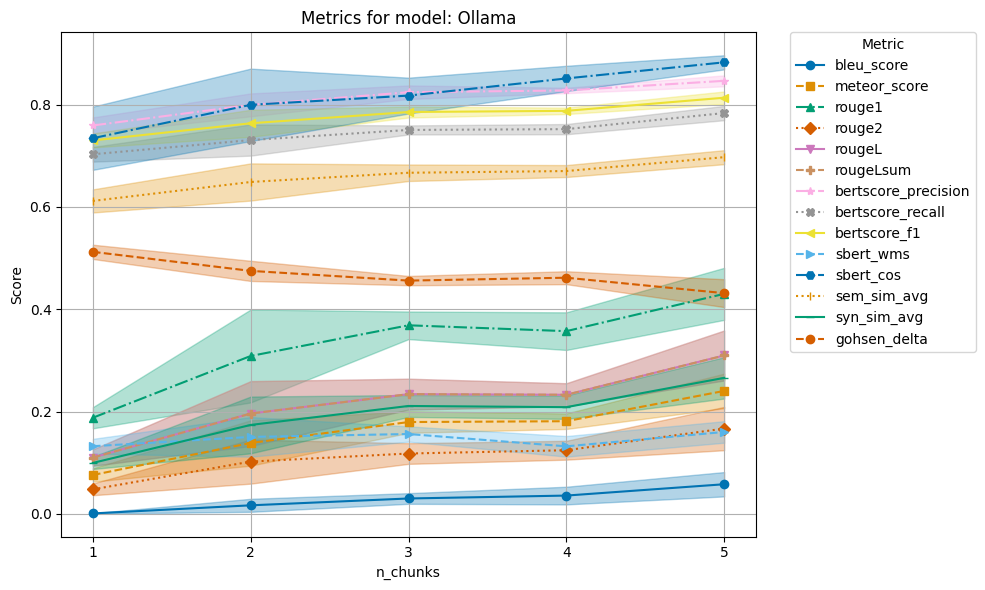

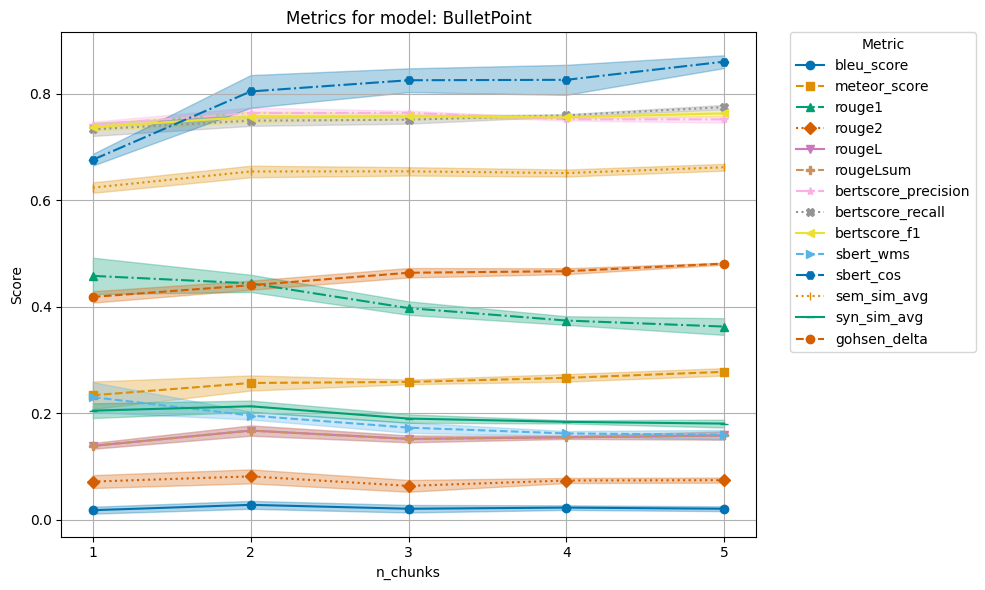

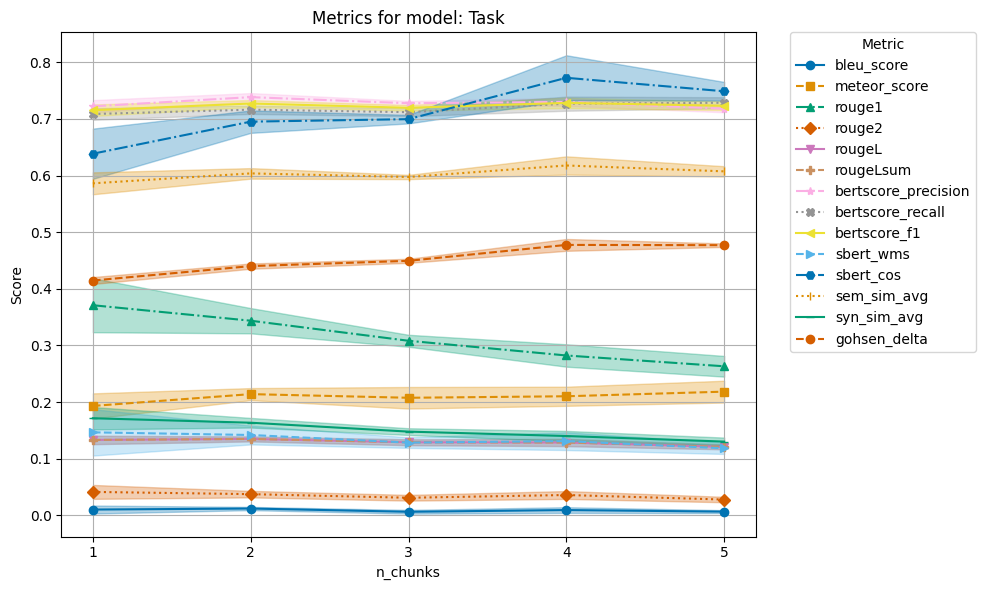

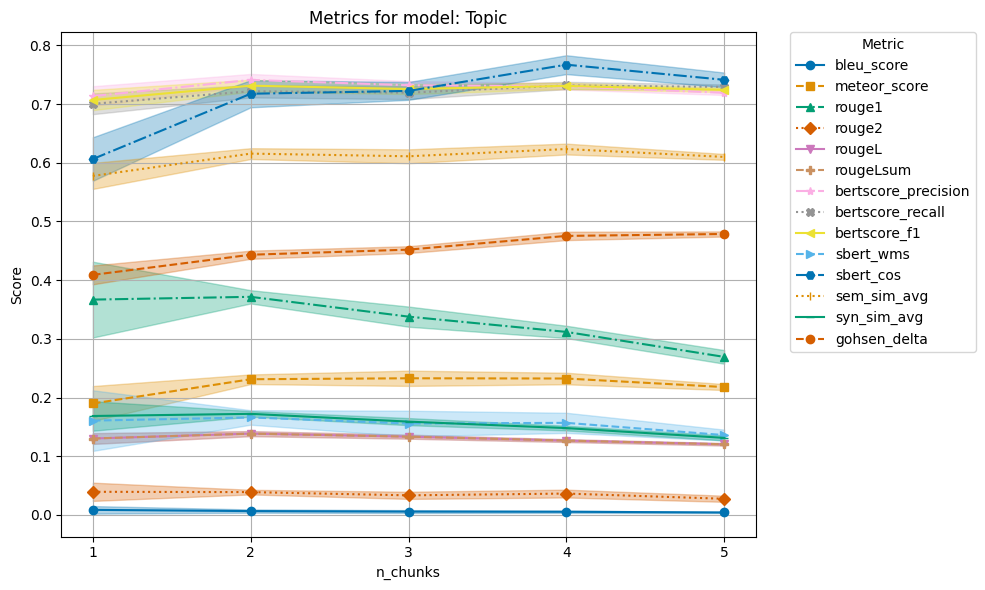

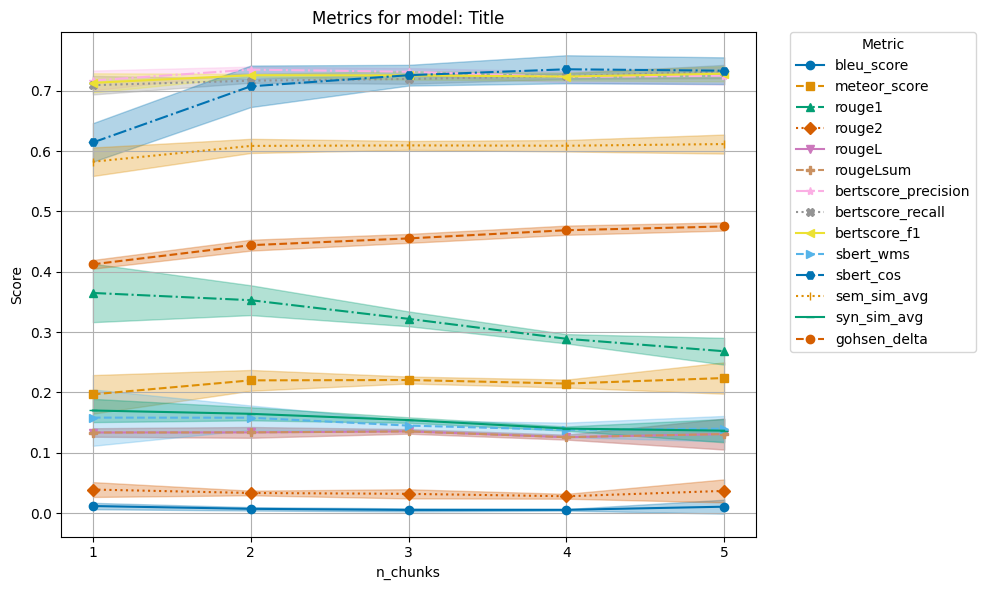

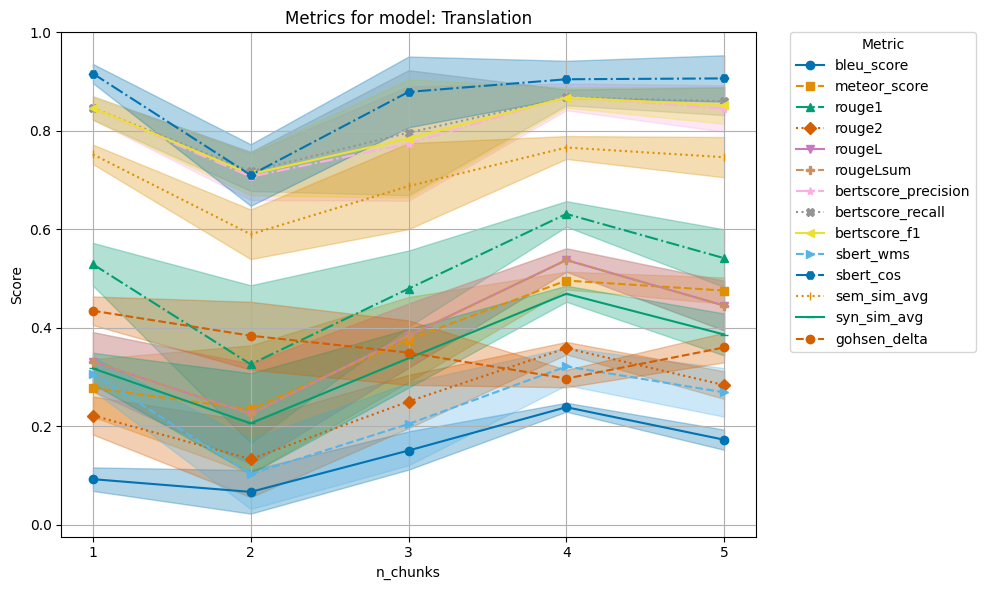

In [ ]:
from matplotlib import cm
from matplotlib.ticker import MaxNLocator


def plot_model_metrics(
    n_paragraphs_df,
    save_dir="model_plots",
    show=True,
    save=True,
    figsize=(10, 6),
    data_category="News",
):
    """
    Create and save line plots of metric scores per model over n_chunks.

    Parameters:
    - n_paragraphs_df: list of pandas DataFrames with columns ['model', 'prompt', 'n_chunks', <metric columns>]
    - save_dir: directory to save plots (default "model_plots")
    - show: whether to display plots using plt.show()
    - save: whether to save plots to disk
    - figsize: figure size for each plot
    """

    # Combine all DataFrames
    combined_df = pd.concat(n_paragraphs_df, ignore_index=True)

    # Identify models and metrics
    models = combined_df["model"].unique()
    metric_cols = [
        col for col in combined_df.columns if col not in ["model", "prompt", "n_chunks"]
    ]

    # Ensure save directory exists
    if save:
        os.makedirs(save_dir, exist_ok=True)

    # Get color map with enough unique colors
    colors = sns.color_palette("colorblind", len(metric_cols))
    line_styles = ["-", "--", "-.", ":"]
    markers = ["o", "s", "^", "D", "v", "P", "*", "X", "<", ">", "H", "|", "_"]

    # Loop over each model
    for model in models:
        df_model = combined_df[combined_df["model"] == model]

        # Group by n_chunks
        grouped = df_model.groupby("n_chunks")
        mean_df = grouped[metric_cols].mean()
        std_df = grouped[metric_cols].std()
        x = mean_df.index

        # Plot
        plt.figure(figsize=figsize)
        for i, metric in enumerate(metric_cols):
            color = colors[i % len(colors)]
            linestyle = line_styles[i % len(line_styles)]
            marker = markers[i % len(markers)]
            plt.plot(
                x,
                mean_df[metric],
                label=metric,
                color=color,
                linestyle=linestyle,
                marker=marker,
            )
            plt.fill_between(
                x,
                mean_df[metric] - std_df[metric],
                mean_df[metric] + std_df[metric],
                color=color,
                alpha=0.3,
            )

        plt.title(f"Metrics for model: {model}")
        plt.xlabel("n_chunks")
        plt.ylabel("Score")
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.legend(
            title="Metric",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            borderaxespad=0.0,
        )
        plt.grid(True)
        plt.tight_layout()

        # Save plot
        if save:
            filename = os.path.join(
                save_dir, f"{model}_metrics_plot_category_{data_category}.svg"
            )
            plt.savefig(filename, format="svg", bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close()


plot_model_metrics(
    slim_n_paragraphs_dfs, save_dir=path2results, data_category=data_category
)